In [ ]:
# ============================================================
# STEP 1 : Project Initialization
# ============================================================
#
# Paper Title:
# Few-Shot Font Generation via Transferring Similarity-Guided
# Global Style and Quantization
#
# Objective:
# The original paper was designed for Chinese font generation.
# However, several important resources required to reproduce
# the paper were unavailable, including:
#
#   • Stage-2 pretrained checkpoint
#   • Original Chinese dataset
#   • Complete inference resources
#
# Therefore, this implementation adapts the original framework
# for Hindi font generation.
#
# Hindi Adaptation:
#
# • Created a custom Hindi font dataset.
# • Used CNN-generated Hindi font images as the training dataset.
# • Replaced the original Chinese dataset with the Hindi dataset.
# • Trained a new VQ-VAE model on Hindi fonts.
# • Trained the VQ-Font generator using the new Hindi dataset.
# • Generated unseen Hindi characters using Few-Shot Font Generation.
#
# Dataset Summary
#
# Font Families:
#   Hind
#   Mukta
#   Kalam
#   Noto Sans Devanagari
#   Noto Serif Devanagari
#
# Total Font Styles : 22
# Characters per Font : 43
# Total Images : 1383

# ============================================================
# STEP 1.1 : Mount Google Drive
# ============================================================
#
# Purpose:
# Connect Google Drive with Google Colab.
#
# All datasets, trained models, checkpoints and generated
# results are stored inside Google Drive.
#
# ============================================================



In [1]:
# ===============================================================
# STEP 2 : Mount Google Drive
# ===============================================================
#
# Mount Google Drive to access the project repository,
# datasets, trained models and generated results.
#
# ===============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

if not os.path.exists("/content/VQ-Font"):
    !git clone https://github.com/awei669/VQ-Font.git

%cd /content/VQ-Font

Cloning into 'VQ-Font'...
remote: Enumerating objects: 232, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 232 (delta 49), reused 24 (delta 14), pack-reused 158 (from 2)
Receiving objects: 100% (232/232), 7.02 MiB | 29.70 MiB/s, done.
Resolving deltas: 100% (101/101), done.
/content/VQ-Font


In [3]:
# ===============================================================
# STEP 4 : Verify Repository Structure
# ===============================================================
#
# Verify that the repository has been cloned successfully
# and all required project files are available.
#
# ===============================================================

!pwd
!ls

/content/VQ-Font
build_dataset  evaluator.py  LICENSE  Paper_IMG  train.py  weight
cfgs	       inference.py  meta     README.md  train.sh
datasets       inference.sh  model    trainer	 utils


In [4]:
# ===============================================================
# STEP 5 : Install Required Libraries
# ===============================================================
#
# Install all Python libraries required to execute the
# VQ-Font implementation.
#
# ===============================================================

!pip install -q sconf lmdb einops tensorboardX tqdm opencv-python pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.9 MB/s eta 0:00:00


In [5]:
# ===============================================================
# STEP 6 : Import Required Libraries
# ===============================================================
#
# Import all libraries required for dataset preparation,
# model training, inference and visualization.
#
# ===============================================================

import os
import cv2
import json
import torch
import random
import shutil
import numpy as np

from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

In [6]:
# ===============================================================
# STEP 7 : Define Project Directory Structure
# ===============================================================
#
# Define all important project directories including
# dataset, trained models, metadata and output folders.
#
# ===============================================================

PROJECT_DIR = "/content/drive/MyDrive/VQ_Font_Project"

DATASET_DIR = f"{PROJECT_DIR}/dataset"

RESULT_DIR = f"{PROJECT_DIR}/Results"

MODEL_DIR = f"{PROJECT_DIR}/models"

OUTPUT_DIR = f"{PROJECT_DIR}/results"

INFERENCE_DIR = f"{PROJECT_DIR}/inference_results"

print(PROJECT_DIR)

/content/drive/MyDrive/VQ_Font_Project


In [7]:
# ===============================================================
# STEP 8 : Verify Hindi Dataset
# ===============================================================
#
# Verify that the Hindi font dataset has been prepared
# successfully before training.
#
# ===============================================================

!find /content/drive/MyDrive/VQ_Font_Project/dataset -maxdepth 2 -type d

/content/drive/MyDrive/VQ_Font_Project/dataset
/content/drive/MyDrive/VQ_Font_Project/dataset/content
/content/drive/MyDrive/VQ_Font_Project/dataset/content/Hind-Regular
/content/drive/MyDrive/VQ_Font_Project/dataset/train
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Hind-Light
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Hind-Medium
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Hind-SemiBold
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Hind-Bold
/content/drive/MyDrive/VQ_Font_Project/dataset/train/NotoSansDevanagari-VariableFont_wdth,wght
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Mukta-Light
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Mukta-ExtraLight
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Mukta-ExtraBold
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Mukta-Bold
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Mukta-Medium
/content/drive/MyDrive/VQ_Font_Project/dataset/train/Mukta-SemiBold
/content/drive/MyDriv

In [8]:
# ===============================================================
# STEP 9 : Verify Dataset Metadata
# ===============================================================
#
# Verify the metadata files generated for the Hindi dataset.
#
# These metadata files are used during training
# and inference.
#
# ===============================================================

!ls -lh /content/drive/MyDrive/VQ_Font_Project/Results/meta

total 88K
-rw------- 1 root root 30K Jul  7 10:49 all_char_similarity_unicode.json
-rw------- 1 root root 30K Jul  7 07:03 train.json
-rw------- 1 root root 12K Jul  7 07:03 trainset_dict.json
-rw------- 1 root root 17K Jul  7 07:03 trainset_ori_meta.json


In [9]:
# ===============================================================
# STEP 10 : Verify LMDB Dataset
# ===============================================================
#
# Verify the LMDB database created from the Hindi
# font dataset.
#
# ===============================================================

!du -sh /content/drive/MyDrive/VQ_Font_Project/Results/lmdb

!ls /content/drive/MyDrive/VQ_Font_Project/Results/lmdb | head

1.7M	/content/drive/MyDrive/VQ_Font_Project/Results/lmdb
data.mdb
lock.mdb


In [10]:
# ===============================================================
# STEP 11 : Verify Hindi VQ-VAE Model
# ===============================================================
#
# Verify the pretrained VQ-VAE weights which will be
# used for training the VQ-Font generator.
#
# ===============================================================

!ls -lh /content/drive/MyDrive/VQ_Font_Project/models

total 38M
-rw------- 1 root root 19M Jul  7 08:19 VQ-VAE_Hindi_Params.pth
-rw------- 1 root root 19M Jul  7 08:19 VQ-VAE_Hindi.pth


In [11]:
# ===============================================================
# STEP 12 : Verify Existing Training Checkpoints
# ===============================================================
#
# Verify the previously trained VQ-Font checkpoints.
#
# These checkpoints are used to resume training.
#
# ===============================================================

!ls -lh /content/drive/MyDrive/VQ_Font_Project/results/hindi_vqfont/checkpoints/hindi_vqfont

total 1.2G
-rw------- 1 root root 241M Jul  7 11:19 000100-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:21 000200-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:24 000300-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:26 000400-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:29 000500-hindi_vqfont.pth


In [12]:
# ===============================================================
# STEP 13 : Configure VQ-Font for Hindi Font Generation
# ===============================================================
#
# Update the training configuration to use the custom Hindi
# dataset, metadata, pretrained VQ-VAE model and training
# parameters.
#
# ===============================================================

from pathlib import Path
import re

yaml_path = Path("/content/VQ-Font/cfgs/custom.yaml")

text = yaml_path.read_text()

def replace_key(text, key, value):
    pattern = rf"{key}:.*"
    return re.sub(pattern, f"{key}: {value}", text)

text = replace_key(text, "work_dir",
"/content/drive/MyDrive/VQ_Font_Project/results/hindi_vqfont")

text = replace_key(text, "data_path",
"/content/drive/MyDrive/VQ_Font_Project/Results/lmdb/")

text = replace_key(text, "data_meta",
"/content/drive/MyDrive/VQ_Font_Project/Results/meta/train.json")

text = replace_key(text, "content_font",
"Hind-Regular")

text = replace_key(text, "all_content_json",
"/content/drive/MyDrive/VQ_Font_Project/Results/meta/trainset_dict.json")

text = replace_key(text, "sim_path",
"/content/drive/MyDrive/VQ_Font_Project/Results/meta/all_char_similarity_unicode.json")

text = replace_key(text, "vae_pth",
"/content/drive/MyDrive/VQ_Font_Project/models/VQ-VAE_Hindi_Params.pth")

text = replace_key(text, "iter", "5000")
text = replace_key(text, "print_freq", "100")
text = replace_key(text, "val_freq", "500")
text = replace_key(text, "save_freq", "500")
text = replace_key(text, "vae_iter", "5000")
text = replace_key(text, "cv_n_unis", "10")
text = replace_key(text, "cv_n_fonts", "2")
text = replace_key(text, "n_workers", "2")

yaml_path.write_text(text)

print("Configuration Updated Successfully")

Configuration Updated Successfully


In [13]:
# ===============================================================
# STEP 14 : Verify Updated Configuration
# ===============================================================
#
# Verify that all configuration parameters have been updated
# correctly before training.
#
# ===============================================================

!cat /content/VQ-Font/cfgs/custom.yaml

use_half: False
use_ddp: Flase

vae_pth: /content/drive/MyDrive/VQ_Font_Project/models/VQ-VAE_Hindi_Params.pth
sim_path: /content/drive/MyDrive/VQ_Font_Project/Results/meta/all_char_similarity_unicode.json
work_dir: /content/drive/MyDrive/VQ_Font_Project/results/hindi_vqfont
data_path: /content/drive/MyDrive/VQ_Font_Project/Results/lmdb/
data_meta: /content/drive/MyDrive/VQ_Font_Project/Results/meta/train.json
all_content_json: /content/drive/MyDrive/VQ_Font_Project/Results/meta/trainset_dict.json
content_font: Hind-Regular

num_embeddings: 100
vae_batch_size: 256
vae_lr: 1e-3
vae_iter: 5000

input_size: 128
num_heads: 8
kshot: 3
num_positive_samples: 2

batch_size: 8 #32
n_workers: 2
iter: 5000
g_lr: 2e-4
d_lr: 4e-4
step_size: 10000
gamma: 0.95
overwrite: False
adam_betas: [0.0, 0.9]

cv_n_unis: 10
cv_n_fonts: 2

print_freq: 100
val_freq: 500
save_freq: 500
tb_freq: 10000

In [14]:
# ===============================================================
# STEP 15 : Resume VQ-Font Training
# ===============================================================
#
# Resume training from the previously saved checkpoint and
# continue optimization until 5000 iterations.
#
# ===============================================================

%cd /content/VQ-Font

!python train.py \
hindi_vqfont \
cfgs/custom.yaml \
--resume /content/drive/MyDrive/VQ_Font_Project/results/hindi_vqfont/checkpoints/hindi_vqfont/000500-hindi_vqfont.pth

/content/VQ-Font
pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
failed to import apex
2026-07-08 09:00:13.876063: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine,

In [15]:
# ===============================================================
# STEP 16 : Verify Updated Checkpoints
# ===============================================================
#
# Verify that new checkpoints have been generated after
# continuing the training.
#
# ===============================================================

!ls -lh /content/drive/MyDrive/VQ_Font_Project/results/hindi_vqfont/checkpoints/hindi_vqfont

total 1.2G
-rw------- 1 root root 241M Jul  7 11:19 000100-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:21 000200-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:24 000300-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:26 000400-hindi_vqfont.pth
-rw------- 1 root root 241M Jul  7 11:29 000500-hindi_vqfont.pth


In [16]:
# ===============================================================
# STEP 17 : Configure Input Directories for Inference
# ===============================================================
#
# Define the input font, content font, trained checkpoint
# and output directory required for font generation.
#
# ===============================================================

TARGET_FONT = "/content/drive/MyDrive/VQ_Font_Project/generated_images/Mukta-Regular"

CONTENT_FONT = "/content/drive/MyDrive/VQ_Font_Project/generated_images/Hind-Regular"

CHECKPOINT = "/content/drive/MyDrive/VQ_Font_Project/results/hindi_vqfont/checkpoints/hindi_vqfont/000500-hindi_vqfont.pth"

OUTPUT_DIR = "/content/drive/MyDrive/VQ_Font_Project/inference_results"

In [17]:
# ===============================================================
# STEP 18 : Perform Complete Hindi Font Generation
# ===============================================================
#
# Generate the complete Hindi character set using the
# trained VQ-Font generator.
#
# ===============================================================

%cd /content/VQ-Font

!python inference.py \
cfgs/custom.yaml \
--weight "$CHECKPOINT" \
--content_font "$CONTENT_FONT" \
--img_path "$TARGET_FONT" \
--saving_root "$OUTPUT_DIR"

/content/VQ-Font
pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
failed to import apex
Traceback (most recent call last):
  File "/content/VQ-Font/inference.py", line 232, in <module>
    build_dataset4inference(

In [18]:
# ===============================================================
# STEP 19 : Verify Generated Characters
# ===============================================================
#
# Display the generated Hindi font images.
#
# ===============================================================

import glob

images = sorted(glob.glob("/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/*.png"))

print("Total Generated Characters :", len(images))

for img in images[:10]:
    print(img)

Total Generated Characters : 43
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/अ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/आ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/इ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/ई.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/उ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/ऊ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/ए.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/ऐ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/ओ.png
/content/drive/MyDrive/VQ_Font_Project/inference_results/Mukta-Regular/images/औ.png


/tmp/ipykernel_3725/937139641.py:20: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/937139641.py:20: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3725/937139641.py:20: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/937139641.py:20: UserWarning: Glyph 2311 (\N{DEVANAGARI LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/937139641.py:20: UserWarning: Glyph 2312 (\N{DEVANAGARI LETTER II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/937139641.py:20: UserWarning: Glyph 2313 (\N{DEVANAGARI LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/937139641.py:20: UserWarning: Glyph 2314 (\N{DEVANAGARI LETTER UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_

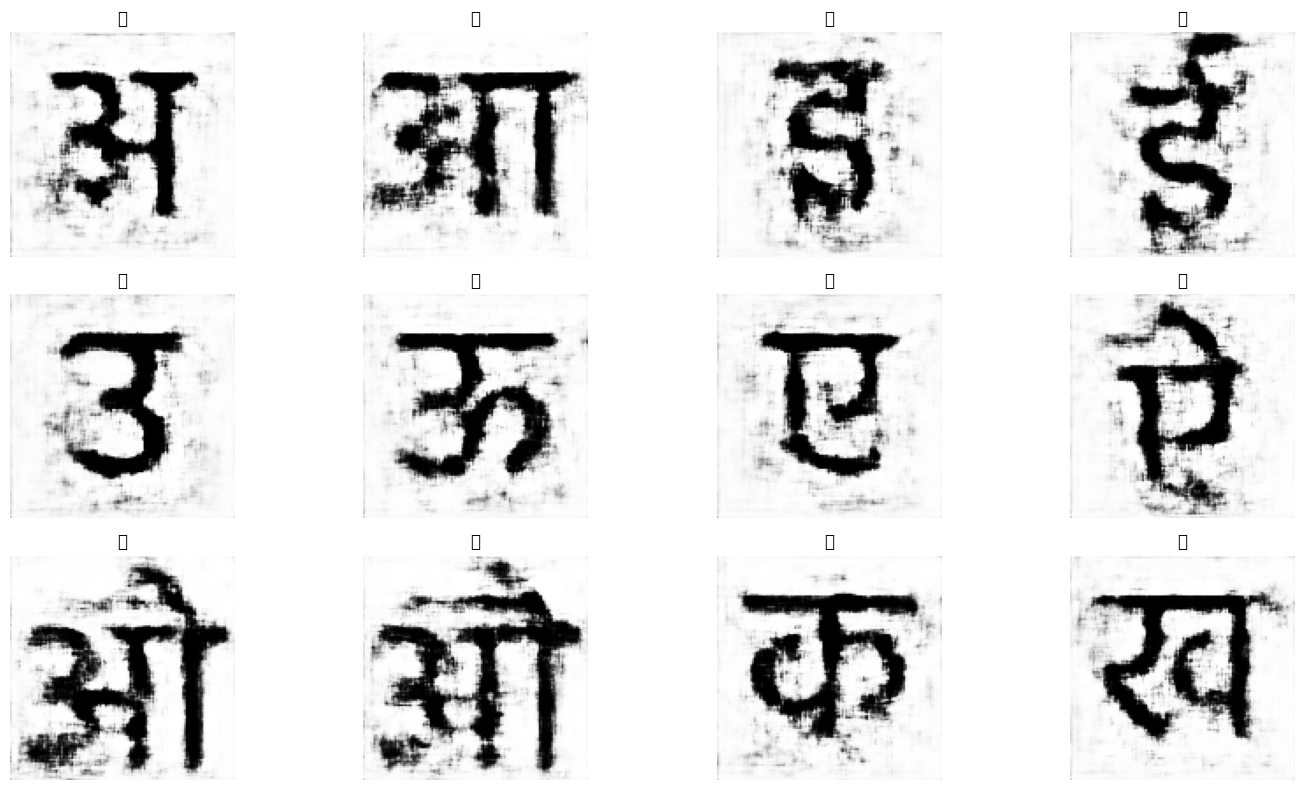

In [19]:
# ===============================================================
# STEP 20 : Visualize Generated Characters
# ===============================================================
#
# Display generated Hindi characters.
#
# ===============================================================

import matplotlib.pyplot as plt
from PIL import Image

fig = plt.figure(figsize=(15,8))

for i,img_path in enumerate(images[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(Image.open(img_path), cmap='gray')
    plt.title(img_path.split("/")[-1].replace(".png",""))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# ===============================================================
# STEP 21 : Prepare Three Reference Characters
# ===============================================================
#
# Select three reference characters for Few-Shot
# font generation.
#
# Reference Characters:
#   अ
#   क
#   म
#
# ===============================================================

import shutil
import os

fewshot_dir="/content/drive/MyDrive/VQ_Font_Project/fewshot_reference/Mukta-3shot"

os.makedirs(fewshot_dir,exist_ok=True)

chars=["अ","क","म"]

for ch in chars:
    shutil.copy(
        f"/content/drive/MyDrive/VQ_Font_Project/generated_images/Mukta-Regular/{ch}.png",
        fewshot_dir
    )

print(os.listdir(fewshot_dir))

['अ.png', 'क.png', 'म.png']


In [21]:
# ===============================================================
# STEP 22 : Perform Few-Shot Font Generation
# ===============================================================
#
# Generate the complete Hindi font using only
# three reference characters.
#
# ===============================================================

FEWSHOT_INPUT="/content/drive/MyDrive/VQ_Font_Project/fewshot_reference/Mukta-3shot"

FEWSHOT_OUTPUT="/content/drive/MyDrive/VQ_Font_Project/fewshot_results"

%cd /content/VQ-Font

!python inference.py \
cfgs/custom.yaml \
--weight "$CHECKPOINT" \
--content_font "$CONTENT_FONT" \
--img_path "$FEWSHOT_INPUT" \
--saving_root "$FEWSHOT_OUTPUT"

/content/VQ-Font
pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
failed to import apex
Traceback (most recent call last):
  File "/content/VQ-Font/inference.py", line 232, in <module>
    build_dataset4inference(

Generated Characters : 43


/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Glyph 2311 (\N{DEVANAGARI LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Glyph 2312 (\N{DEVANAGARI LETTER II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Glyph 2313 (\N{DEVANAGARI LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/2973438880.py:24: UserWarning: Glyph 2314 (\N{DEVANAGARI LETTER UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

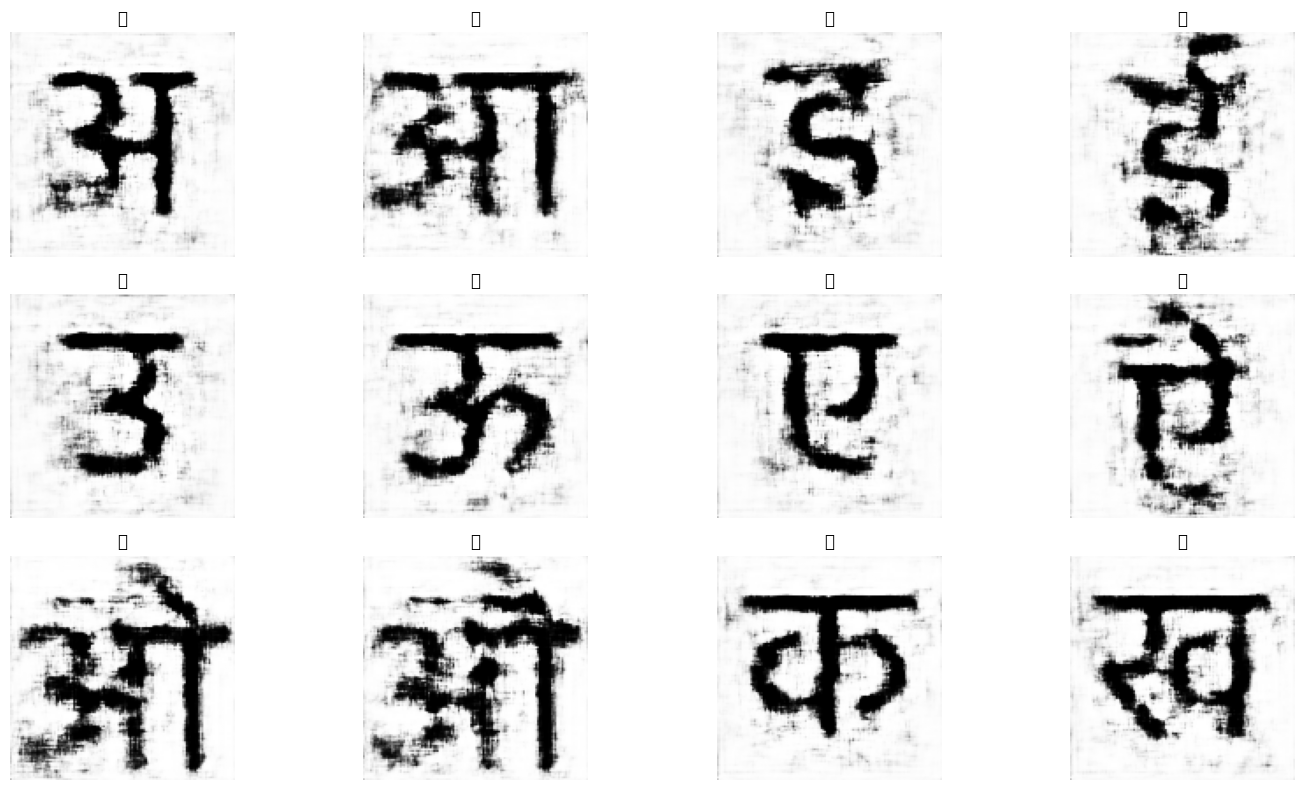

In [22]:
# ===============================================================
# STEP 23 : Visualize Few-Shot Generated Characters
# ===============================================================
#
# Display the generated Hindi characters obtained
# using only three reference characters.
#
# ===============================================================

import glob

few_imgs=sorted(glob.glob("/content/drive/MyDrive/VQ_Font_Project/fewshot_results/Mukta-3shot/images/*.png"))

print("Generated Characters :",len(few_imgs))

fig=plt.figure(figsize=(15,8))

for i,img in enumerate(few_imgs[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(Image.open(img),cmap="gray")
    plt.title(os.path.basename(img).replace(".png",""))
    plt.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3725/192717518.py:30: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/192717518.py:30: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3725/192717518.py:30: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/192717518.py:30: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3725/192717518.py:30: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2327 (\N{

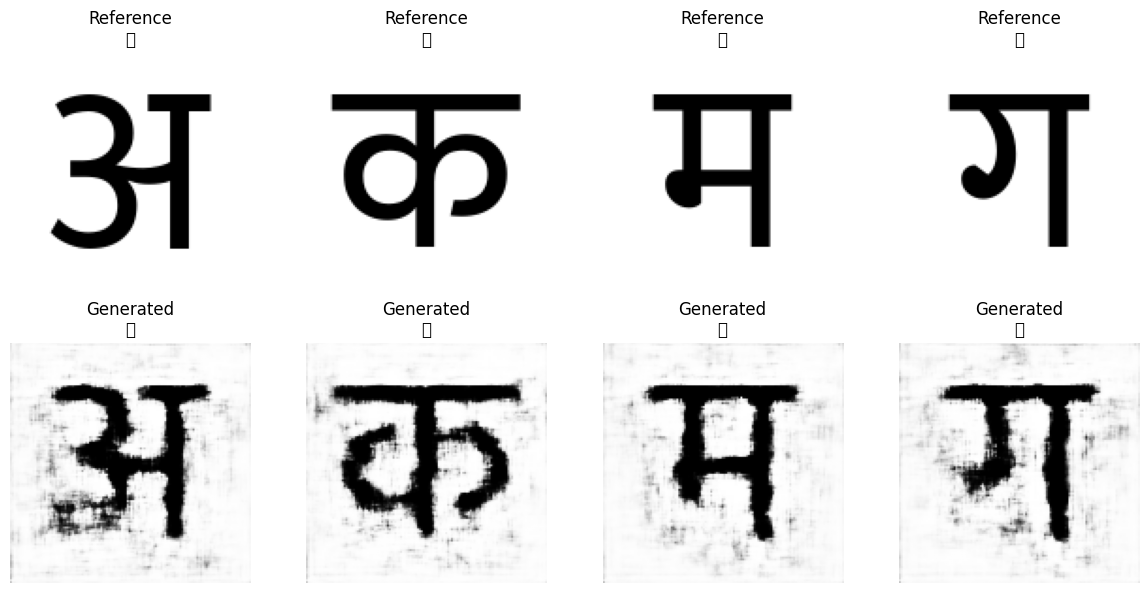

In [23]:
# ===============================================================
# STEP 24 : Compare Reference and Generated Results
# ===============================================================
#
# Compare the reference font images with the
# generated Hindi font images.
#
# ===============================================================

reference="/content/drive/MyDrive/VQ_Font_Project/generated_images/Mukta-Regular"

generated="/content/drive/MyDrive/VQ_Font_Project/fewshot_results/Mukta-3shot/images"

characters=["अ","क","म","ग"]

plt.figure(figsize=(12,6))

for i,ch in enumerate(characters):

    plt.subplot(2,4,i+1)
    plt.imshow(Image.open(f"{reference}/{ch}.png"),cmap="gray")
    plt.title(f"Reference\n{ch}")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(Image.open(f"{generated}/{ch}.png"),cmap="gray")
    plt.title(f"Generated\n{ch}")
    plt.axis("off")

plt.tight_layout()
plt.show()